In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNetCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import normaltest, skew, boxcox

In [3]:
df = pd.read_csv(
    filepath_or_buffer = 'data/FuelConsumption.csv'
)

df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [4]:
df.shape

(1067, 13)

In [5]:
df.columns

Index(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS',
       'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY',
       'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
       'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS'],
      dtype='object')

In [6]:
df.drop(
    columns=['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE'],
    inplace=True
)

In [7]:
df.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2.0,4,9.9,6.7,8.5,33,196
1,2.4,4,11.2,7.7,9.6,29,221
2,1.5,4,6.0,5.8,5.9,48,136
3,3.5,6,12.7,9.1,11.1,25,255
4,3.5,6,12.1,8.7,10.6,27,244


In [8]:
df.corr()['CO2EMISSIONS'].sort_values(ascending=False)

CO2EMISSIONS                1.000000
FUELCONSUMPTION_CITY        0.898039
FUELCONSUMPTION_COMB        0.892129
ENGINESIZE                  0.874154
FUELCONSUMPTION_HWY         0.861748
CYLINDERS                   0.849685
FUELCONSUMPTION_COMB_MPG   -0.906394
Name: CO2EMISSIONS, dtype: float64

In [9]:
df.describe()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [10]:
def normality_report(data_set: pd.DataFrame) -> pd.DataFrame:
    results = []
    for col in data_set.select_dtypes(include='number').columns:
        stat, p = normaltest(data_set[col].dropna())
        normal = p > 0.05

        results.append({
            'Column': col,
            'K2 Statistic': round(stat, 3),
            'p-value': p,
            'Is Normal': 'Yes' if normal else 'No',
            'Interpreration': ('Fit Normal Distribution' if normal else 'Not Fir Normal Distribution')
        })

    return pd.DataFrame(results)

In [11]:
normal_test_result = normality_report(data_set=df)

normal_test_result

,Column,K2 Statistic,p-value,Is Normal,Interpreration
0,ENGINESIZE,75.054,5.037421e-17,No,Not Fir Normal Distribution
1,CYLINDERS,97.043,8.458244e-22,No,Not Fir Normal Distribution
2,FUELCONSUMPTION_CITY,129.822,6.448141e-29,No,Not Fir Normal Distribution
3,FUELCONSUMPTION_HWY,229.154,1.736772e-50,No,Not Fir Normal Distribution
4,FUELCONSUMPTION_COMB,163.716,2.815374e-36,No,Not Fir Normal Distribution
5,FUELCONSUMPTION_COMB_MPG,67.915,1.788234e-15,No,Not Fir Normal Distribution
6,CO2EMISSIONS,43.711,3.222627e-10,No,Not Fir Normal Distribution


In [12]:
def skewness_report(data_set: pd.DataFrame) -> pd.DataFrame:
    results = []
    for col in data_set.select_dtypes(include='number').columns:
        data = data_set[col].dropna()
        skew_val = skew(data)
        if skew_val > 0.5:
            direction = 'Right-Skewed'
        elif skew_val < -0.5:
            direction = 'Left-Skewed'
        else:
            direction = 'Simetric'
        
        abs_val = abs(skew_val)
        if abs_val < 0.5:
            severity = '~Simetric'
        elif abs_val < 1:
            severity = 'Low skewed'
        elif abs_val < 2:
            severity = 'Medium skewed'
        else:
            severity = 'Heavy skewed'
        
        results.append({
            'Column': col,
            'Skewness': round(skew_val, 3),
            'Direction': direction,
            'Severity': severity
        })

    return (
        pd.DataFrame(results)
            .sort_values(
                by='Skewness',
                ascending=False
            )
            .reset_index(drop=True)
    )

In [13]:
skewness_result = skewness_report(data_set=df)
skewness_result

,Column,Skewness,Direction,Severity
0,FUELCONSUMPTION_HWY,1.262,Right-Skewed,Medium skewed
1,FUELCONSUMPTION_COMB,1.031,Right-Skewed,Medium skewed
2,FUELCONSUMPTION_CITY,0.899,Right-Skewed,Low skewed
3,CYLINDERS,0.795,Right-Skewed,Low skewed
4,FUELCONSUMPTION_COMB_MPG,0.585,Right-Skewed,Low skewed
5,ENGINESIZE,0.567,Right-Skewed,Low skewed
6,CO2EMISSIONS,0.519,Right-Skewed,Low skewed


In [14]:
box_df = df.copy()

for col in df.columns:
    box_df[col], _ = boxcox(df[col])

box_df.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,0.720432,0.998389,2.202310,1.055183,1.585580,6.193556,7.537389
1,0.919293,0.998389,2.315860,1.090531,1.649048,5.830644,7.774941
2,0.414702,0.998389,1.736325,1.014736,1.380861,7.329359,6.836259
3,1.343783,1.181131,2.431028,1.128701,1.721834,5.430828,8.062915
4,1.343783,1.181131,2.386742,1.118862,1.699064,5.635917,7.973616


In [15]:
skewness_report_v1 = skewness_report(data_set=box_df)
skewness_report_v1

,Column,Skewness,Direction,Severity
0,CYLINDERS,0.063,Simetric,~Simetric
1,FUELCONSUMPTION_HWY,0.026,Simetric,~Simetric
2,FUELCONSUMPTION_COMB,0.005,Simetric,~Simetric
3,FUELCONSUMPTION_CITY,-0.000,Simetric,~Simetric
4,CO2EMISSIONS,-0.003,Simetric,~Simetric
5,FUELCONSUMPTION_COMB_MPG,-0.004,Simetric,~Simetric
6,ENGINESIZE,-0.016,Simetric,~Simetric


In [16]:
box_df.corr()['CO2EMISSIONS'].sort_values(ascending=False)

CO2EMISSIONS                1.000000
FUELCONSUMPTION_COMB        0.937837
FUELCONSUMPTION_CITY        0.934204
FUELCONSUMPTION_HWY         0.917397
ENGINESIZE                  0.870349
CYLINDERS                   0.848225
FUELCONSUMPTION_COMB_MPG   -0.936724
Name: CO2EMISSIONS, dtype: float64

<Axes: >

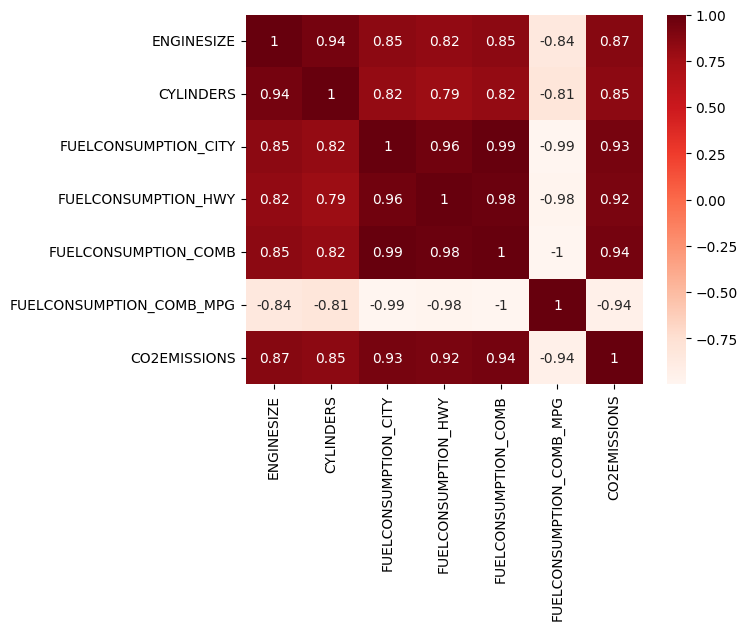

In [17]:
dpi = 100
plt.figure(dpi=dpi)
sns.heatmap(
    np.round(box_df.corr(), 3),
    annot=True,
    cmap='Reds'
)

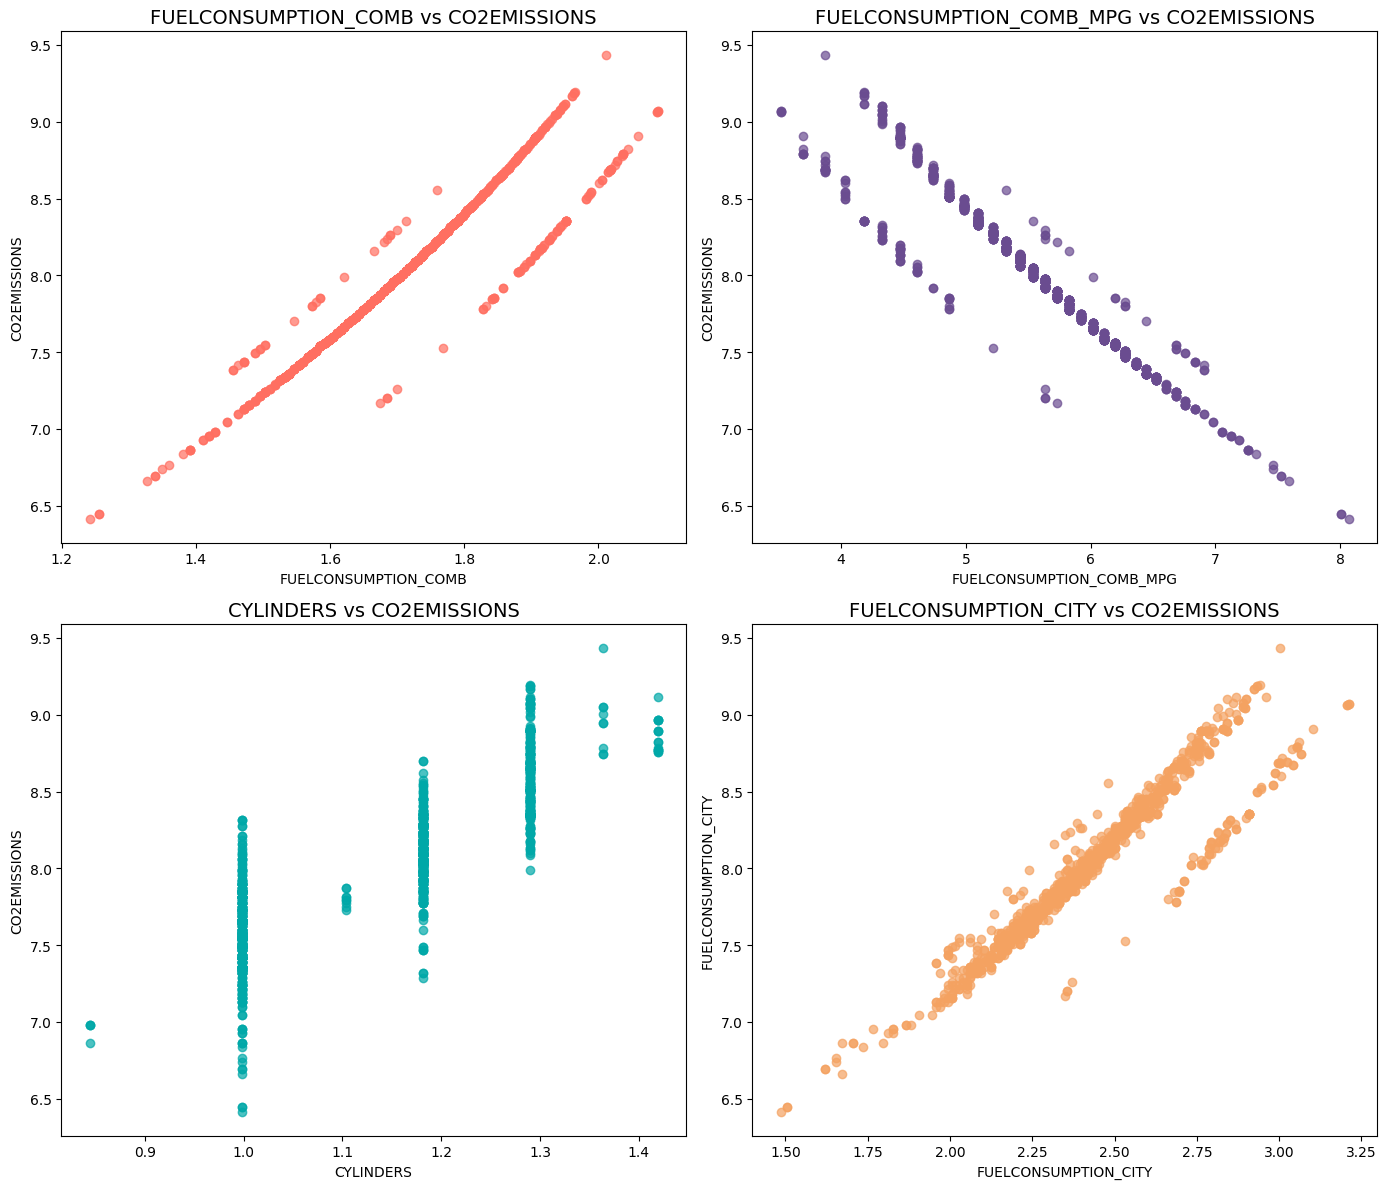

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

special_colors = [
    "#FF6F61", "#6A4C90", "#00A8A8", "#F4A261", "#3B9DF5"
]

axes[0, 0].scatter(box_df['FUELCONSUMPTION_COMB'], box_df['CO2EMISSIONS'], color=special_colors[0], alpha=0.7)
axes[0, 0].set_title('FUELCONSUMPTION_COMB vs CO2EMISSIONS', fontsize=14, color='black')
axes[0, 0].set_xlabel('FUELCONSUMPTION_COMB', fontsize=10, color='black')
axes[0, 0].set_ylabel('CO2EMISSIONS', fontsize=10, color='black')

axes[0, 1].scatter(box_df['FUELCONSUMPTION_COMB_MPG'], box_df['CO2EMISSIONS'], color=special_colors[1], alpha=0.7)
axes[0, 1].set_xlabel('FUELCONSUMPTION_COMB_MPG', fontsize=10, color='black')
axes[0, 1].set_ylabel('CO2EMISSIONS', fontsize=10, color='black')
axes[0, 1].set_title('FUELCONSUMPTION_COMB_MPG vs CO2EMISSIONS', fontsize=14, color='black')

axes[1, 0].scatter(box_df['CYLINDERS'], box_df['CO2EMISSIONS'], color=special_colors[2], alpha=0.7)
axes[1, 0].set_title('CYLINDERS vs CO2EMISSIONS', fontsize=14, color='black')
axes[1, 0].set_xlabel('CYLINDERS', fontsize=10, color='black')
axes[1, 0].set_ylabel('CO2EMISSIONS', fontsize=10, color='black')

axes[1, 1].scatter(box_df['FUELCONSUMPTION_CITY'], box_df['CO2EMISSIONS'], color=special_colors[3], alpha=0.7)
axes[1, 1].set_title('FUELCONSUMPTION_CITY vs CO2EMISSIONS', fontsize=14, color='black')
axes[1, 1].set_xlabel('FUELCONSUMPTION_CITY', fontsize=10, color='black')
axes[1, 1].set_ylabel('FUELCONSUMPTION_CITY', fontsize=10, color='black')

plt.tight_layout()

plt.show()

In [19]:
cdf = box_df[['ENGINESIZE', 'CO2EMISSIONS']]

cdf.head()

,ENGINESIZE,CO2EMISSIONS
0,0.720432,7.537389
1,0.919293,7.774941
2,0.414702,6.836259
3,1.343783,8.062915
4,1.343783,7.973616


In [20]:
train_df, test_df = train_test_split(cdf, train_size=0.8, random_state=42)

print(
    f'Train Set: {train_df.shape}\n'
    f'Test Set: {test_df.shape}'
)

Train Set: (853, 2)
Test Set: (214, 2)


In [21]:
regression = LinearRegression(
    fit_intercept=True,
    copy_X=True,
    n_jobs=-1
)

train_x = np.asarray(train_df[['ENGINESIZE']])
train_y = np.asarray(train_df[['CO2EMISSIONS']])

regression.fit(train_x, train_y)

coefficient = regression.coef_[0][0]
intercept = regression.intercept_[0]

print(
    f'Coefficient: {coefficient}\n'
    f'Intercept: {intercept}'
)

Coefficient: 0.8804018250732677
Intercept: 6.967651694315688


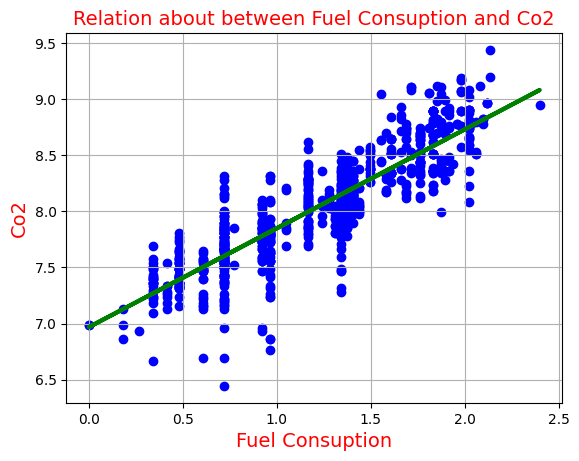

In [22]:
plt.scatter(train_df['ENGINESIZE'], train_df['CO2EMISSIONS'], color='blue')
plt.plot(train_x, coefficient * train_x + intercept, c='green', lw=3)
plt.title(label='Relation about between Fuel Consuption and Co2', color='red', fontsize=14)
plt.xlabel(xlabel='Fuel Consuption', color='red', fontsize=14)
plt.ylabel(ylabel='Co2', color='red', fontsize=14)
plt.grid()
plt.show()

In [23]:
test_x = np.asarray(test_df[['ENGINESIZE']])
test_y = np.asarray(test_df[['CO2EMISSIONS']])

# y = intecpt + coefficient * x
test_prediction = regression.predict(test_x)

result_df = pd.DataFrame({
    'Real Values': test_y.flatten(),
    'Estimated Values': test_prediction.flatten()
})

result_df.head()

,Real Values,Estimated Values
0,8.423906,8.453786
1,7.774941,8.150720
2,8.354583,8.179256
3,7.774941,7.996141
4,7.644989,7.601921


In [24]:
r2_score = r2_score(y_true=test_y, y_pred=test_prediction)
print(f'R2 Score: {r2_score:.2f}')

R2 Score: 0.75


In [25]:
mae = mean_absolute_error(y_true=test_y, y_pred=test_prediction)
print(f'Mean Absolute Error: {mae:.2f}')

Mean Absolute Error: 0.20


In [26]:
mse = mean_squared_error(y_true=test_y, y_pred=test_prediction)
print(f'Mean Squared Error: {mse:.2f}')

Mean Squared Error: 0.07


In [28]:
y = coefficient * 2.2 + intercept
y

np.float64(8.904535709476876)